In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AI_Resume_Screening.csv to AI_Resume_Screening.csv


In [ ]:
import pandas as pd
df=pd.read_csv("AI_Resume_Screening.csv")
df.head(10)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
5,6,Samantha Santos,"Cybersecurity, Networking, Linux, Ethical Hacking",10,B.Tech,Google ML,Cybersecurity Analyst,Hire,47957,5,100
6,7,Tony Smith,"Networking, Cybersecurity, Ethical Hacking",4,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,66208,9,100
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,Hire,103006,7,90
8,9,Nancy Jenkins,"Networking, Ethical Hacking",7,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,92270,3,100
9,10,Courtney Gibson,"Python, TensorFlow, Pytorch, NLP",0,M.Tech,AWS Certified,AI Researcher,Reject,60579,1,35


In [ ]:
df=pd.DataFrame(df)
df

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
...,...,...,...,...,...,...,...,...,...,...,...
995,996,Brenda Williams,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,NaN,Cybersecurity Analyst,Reject,114364,9,60
996,997,Colleen Hicks,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,998,Michelle Molina,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,Hire,113855,9,65
998,999,Danielle Horn,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,Hire,83146,10,100


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [ ]:
df['Certifications']=df['Certifications'].fillna("No")

In [ ]:
df.isna().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
cleaned_df=df.drop(['Name'], axis=1)

In [ ]:
cleaned_df.columns

Index(['Resume_ID', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [ ]:
y=cleaned_df['Recruiter Decision']
x=cleaned_df.drop(['Recruiter Decision'], axis=1)

In [ ]:
x_encode=pd.get_dummies(x,drop_first=False)
x_encode.head()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java","Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React",...,Education_MBA,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_No,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
0,1,10,104895,8,100,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
1,2,10,113002,1,100,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,3,1,71766,7,70,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
3,4,7,46848,0,95,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
4,5,4,87441,9,100,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
cleaned_df=pd.concat([x_encode,y],axis=1)
cleaned_df.head()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java","Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React",...,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_No,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,Recruiter Decision
0,1,10,104895,8,100,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,Hire
1,2,10,113002,1,100,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,Hire
2,3,1,71766,7,70,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,Hire
3,4,7,46848,0,95,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,Hire
4,5,4,87441,9,100,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,Hire


In [ ]:
cleaned_df["Recruiter Decision"]=cleaned_df["Recruiter Decision"].map({"Hire":1,"Reject":0})
cleaned_df.head()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java","Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React",...,Certifications_Google ML,Certifications_No,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,Recruiter Decision,recruiter_decision,Recruiter_decision,Recruiter_Decision
0,1,10,104895,8,100,False,False,False,False,False,...,False,True,True,False,False,False,1,1,1,1
1,2,10,113002,1,100,False,False,False,False,False,...,True,False,False,False,True,False,1,1,1,1
2,3,1,71766,7,70,False,False,False,False,False,...,False,False,False,True,False,False,1,1,1,1
3,4,7,46848,0,95,False,False,False,False,False,...,False,False,True,False,False,False,1,1,1,1
4,5,4,87441,9,100,False,False,False,False,False,...,False,True,False,False,False,True,1,1,1,1


In [ ]:
cols_to_drop=['recruiter_decision','Recruiter_decision',	'Recruiter_Decision']
cleaned_df= cleaned_df.drop(columns=cols_to_drop, errors='ignore')
cleaned_df.head(10)

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java","Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React",...,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_No,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,Recruiter Decision
0,1,10,104895,8,100,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,1
1,2,10,113002,1,100,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,1
2,3,1,71766,7,70,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,1
3,4,7,46848,0,95,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,1
4,5,4,87441,9,100,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,1
5,6,10,47957,5,100,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,1
6,7,4,66208,9,100,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,1
7,8,3,103006,7,90,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,1
8,9,7,92270,3,100,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,1
9,10,0,60579,1,35,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,0


In [ ]:
cleaned_df=cleaned_df.astype(int)
cleaned_df.head(10)

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),"Skills_C++, Java","Skills_C++, Java, React","Skills_C++, Java, React, SQL","Skills_C++, Java, SQL","Skills_C++, Java, SQL, React",...,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_No,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,Recruiter Decision
0,1,10,104895,8,100,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1
1,2,10,113002,1,100,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
2,3,1,71766,7,70,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
3,4,7,46848,0,95,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,5,4,87441,9,100,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,1
5,6,10,47957,5,100,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
6,7,4,66208,9,100,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1
7,8,3,103006,7,90,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
8,9,7,92270,3,100,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
9,10,0,60579,1,35,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


In [ ]:
cleaned_df.dtypes

,0
Resume_ID,int64
Experience (Years),int64
Salary Expectation ($),int64
Projects Count,int64
AI Score (0-100),int64
...,...
Job Role_AI Researcher,int64
Job Role_Cybersecurity Analyst,int64
Job Role_Data Scientist,int64
Job Role_Software Engineer,int64


In [ ]:
cleaned_df.columns

Index(['Resume_ID', 'Experience (Years)', 'Salary Expectation ($)',
       'Projects Count', 'AI Score (0-100)', 'Skills_C++, Java',
       'Skills_C++, Java, React', 'Skills_C++, Java, React, SQL',
       'Skills_C++, Java, SQL', 'Skills_C++, Java, SQL, React',
       ...
       'Education_PhD', 'Certifications_AWS Certified',
       'Certifications_Deep Learning Specialization',
       'Certifications_Google ML', 'Certifications_No',
       'Job Role_AI Researcher', 'Job Role_Cybersecurity Analyst',
       'Job Role_Data Scientist', 'Job Role_Software Engineer',
       'Recruiter Decision'],
      dtype='object', length=257)

In [ ]:
from sklearn.model_selection import train_test_split
y=cleaned_df['Recruiter Decision']
x=cleaned_df.drop(['Recruiter Decision'], axis=1)
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
len(X_train)

800

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predict=model.predict(X_test)
y_predict


array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1])

In [ ]:
model.score(X_test,Y_test)

0.89

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(Y_test,y_predict)
cm


array([[ 24,  14],
       [  8, 154]])

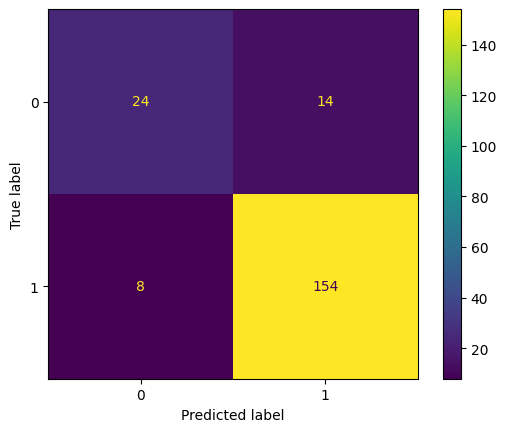

In [ ]:
label=model.classes_
from matplotlib import pyplot as plt
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label)
display.plot()
plt.show()

In [ ]:
import pandas as pd
cm_df=pd.DataFrame(
    cm,
    index=["Actual no","Actual yes"],
    columns=["Predicted no","Predicted yes"]
)
cm_df

,Predicted no,Predicted yes
Actual no,24,14
Actual yes,8,154


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_predict)

0.89

In [ ]:
cleaned_df.columns

Index(['Resume_ID', 'Experience (Years)', 'Salary Expectation ($)',
       'Projects Count', 'AI Score (0-100)', 'Skills_C++, Java',
       'Skills_C++, Java, React', 'Skills_C++, Java, React, SQL',
       'Skills_C++, Java, SQL', 'Skills_C++, Java, SQL, React',
       ...
       'Education_PhD', 'Certifications_AWS Certified',
       'Certifications_Deep Learning Specialization',
       'Certifications_Google ML', 'Certifications_No',
       'Job Role_AI Researcher', 'Job Role_Cybersecurity Analyst',
       'Job Role_Data Scientist', 'Job Role_Software Engineer',
       'Recruiter Decision'],
      dtype='object', length=257)

# Fairness Analysis using Education

In [ ]:
df['Education'].value_counts()


,count
Education,
B.Sc,205
MBA,202
B.Tech,200
M.Tech,198
PhD,195


In [ ]:
education_fairness = (
    pd.DataFrame({
        'Education': df['Education'],
        'Recruiter Decision': cleaned_df['Recruiter Decision']
    }).groupby('Education')['Recruiter Decision'].mean())
education_fairness

,Recruiter Decision
Education,
B.Sc,0.790244
B.Tech,0.830000
M.Tech,0.797980
MBA,0.816832
PhD,0.825641


Here we calculated Selection rates, which varied across education levels, but according to values observed percentage of selection rate is pretty close to each other.This indicates that there is no education-based bias in the screening process

# Fairness Analysis using Experience

In [ ]:
df['Exp_Group'] = cleaned_df['Experience (Years)'].apply(lambda x: 'Fresher' if x <= 2 else 'Experienced')
exp_fairness = (df.groupby('Exp_Group')['Recruiter Decision'].apply(lambda x: (x == 'Hire').mean()))
exp_fairness


,Recruiter Decision
Exp_Group,
Experienced,0.960110
Fresher,0.417582


Experienced candidates showed higher selection rates compared to freshers suggesting that experience level significantly influenced screening decisions.


Since the model may favor experienced candidates, I suggested that resumes with low experience but good education should be manually reviewed instead of being automatically rejected
